[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yzyouzhang/dafx2026-hrtf-tutorial/blob/main/00_data_and_sampling.ipynb)

<!-- TODO: "main" is a placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date -->


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os

    REPO_NAME = "dafx2026-hrtf-tutorial"
    REPO_URL = "https://github.com/yzyouzhang/dafx2026-hrtf-tutorial.git"
    BRANCH = "main"  # TODO: placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date

    if os.path.basename(os.getcwd()) != REPO_NAME:
        if not os.path.isdir(REPO_NAME):
            !git clone -b {BRANCH} {REPO_URL}
        %cd {REPO_NAME}

    if os.path.exists("requirements.txt"):
        !pip install -q -r requirements.txt
    else:
        print("WARNING: requirements.txt not found at repo root -- dependencies were not installed; install manually.")

# 00 — HRTF Basics & Directional Sampling (SONICOM)

**DAFx 2026 Tutorial: From Neural Fields to Personalized Spatial Audio**
Neil Zhang & Yoshiki Masuyama

This notebook covers:
1. Loading a SONICOM subject's HRIR data from a real `.sofa` file
2. **HRTF basics** — monaural vs. stereo vs. binaural, and what an HRIR/HRTF looks like at a few canonical directions
3. Visualizing SONICOM's full directional sampling pattern (793 directions/subject — not a uniform grid, which is exactly why neural fields are useful)

> **Data note:** Get SONICOM `.sofa` files from the [SONICOM HRTF dataset](https://www.sonicom.eu/tools-and-resources/hrtf-dataset/) and place them in the `data/` folder (already done for this tutorial) — the notebook automatically loads every `.sofa` file it finds there. If `data/` is empty, this notebook falls back to **synthetic data shaped exactly like SONICOM's real grid** (793 directions: 72 azimuths x SONICOM's elevation spacing, KEMAR-arch measurement pattern) so the rest of the pipeline is runnable and testable today.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import os
import glob

from src.data import load_real_sonicom, load_real_sonicom_dir, synthesize_sonicom_like, hrir_to_hrtf_db

np.random.seed(0)

# Directory of real SONICOM .sofa files (p0001.sofa .. p0030.sofa) — used by default.
SOFA_DIR = "data/sonicom"
# Single-file override (only used if SOFA_DIR has no .sofa files):
SOFA_PATH = None   # e.g. "data/p0001.sofa"

## 1. Load (or synthesize) a SONICOM subject

SONICOM's real measurement grid (per the dataset paper): 793 source positions per subject, at 1.5m distance, azimuth sampled every 5° (72 azimuths), elevation from -45° to 90° (every 10° between -30°/30°, every 15° outside that band, single measurement at the +90° pole).

`sofar` reads the actual SOFA convention (`SimpleFreeFieldHRIR`) once you have a real file — `Data.IR` gives HRIRs shaped `[n_positions, 2, n_taps]`, `SourcePosition` gives `[n_positions, 3]` (azimuth, elevation, distance).

In [2]:
if SOFA_DIR and os.path.isdir(SOFA_DIR) and glob.glob(os.path.join(SOFA_DIR, "*.sofa")):
    hrir, positions, subject_ids, fs = load_real_sonicom_dir(SOFA_DIR)
    print(f"Loaded {hrir.shape[0]} real SONICOM subjects from '{SOFA_DIR}/'.")
elif SOFA_PATH:
    hrir_single, positions, fs = load_real_sonicom(SOFA_PATH)
    hrir = hrir_single[None, ...]
    subject_ids = np.array(["real_subject"])
    print("Loaded real SONICOM subject.")
else:
    hrir, positions, subject_ids, fs = synthesize_sonicom_like()
    print("Using synthetic placeholder data shaped like SONICOM's real grid — set SOFA_PATH or add .sofa files to data/ for the real subset.")

print("hrir shape:", hrir.shape, "(subjects, directions, ears, taps)")
print("positions shape:", positions.shape, "(directions, [az, el, dist])")
print("subjects:", list(subject_ids))
print("fs:", fs)

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
Loaded 30 real SONICOM subjects from 'data/'.
hrir shape: (30, 828, 2, 256) (subjects, directions, ears, taps)
positions shape: (828, 3) (directions, [az, el, dist])
subjects: [np.str_('p0001'), np.str_('p0002'), np.str_('p0003'), np.str_('p0004'), np.str_('p0005'), np.str_('p0006'), np.str_('p0007'), np.str_('p0008'), np.str_('p0009'), np.str_('p0010'), np.str_('p0011'), np.str_('p0012'), np.str_('p0013'), np.str_('p0014'), np.str_('p0015'), np.str_('p0016'), np.str_('p0017'), np.str_('p0018'), np.str_('p0019'), np.str_('p0020'), np.str_('p0

## 2. HRTF basics

**Monaural, stereo, and binaural** are three different ways of delivering sound to a listener:
- *Monaural*: a single channel — no spatial information at all.
- *Stereo*: two channels (e.g. left/right speakers), giving a left-right sense of balance but not built from the listener's own ears.
- *Binaural*: two channels specifically captured or synthesized **as they would arrive at the two eardrums**, including the filtering effects of the head, torso, and (especially) the pinna. This is what makes binaural audio, unlike plain stereo, capable of conveying full 3D direction — including front/back and elevation, not just left/right.

A **Head-Related Impulse Response (HRIR)** is the time-domain filter that captures this ear-specific, direction-dependent filtering for one source direction; its frequency-domain counterpart is the **HRTF**. Every direction has its own HRIR/HRTF pair per ear, which is exactly why HRTF data is an irregular, high-dimensional function of direction rather than a single filter.

Below we look at three canonical directions on the horizontal plane (elevation 0°): straight ahead, and the two lateral sides. Note azimuth convention differs across datasets (SONICOM uses 0–355° increasing on the horizontal plane) — we're plotting by explicit azimuth value rather than assuming which side is "left" vs "right" without checking the convention of whatever real file you load.

In [3]:
def nearest_direction(positions, target_az, target_el):
    # Great-circle (haversine) distance, treating elevation as latitude and
    # azimuth as longitude -- a naive Euclidean (az, el) distance distorts
    # badly near the poles, where large azimuth changes cover little ground.
    az, el = np.deg2rad(positions[:, 0]), np.deg2rad(positions[:, 1])
    target_az_rad, target_el_rad = np.deg2rad(target_az), np.deg2rad(target_el)
    dlat = el - target_el_rad
    dlon = az - target_az_rad
    hav = np.sin(dlat / 2) ** 2 + np.cos(el) * np.cos(target_el_rad) * np.sin(dlon / 2) ** 2
    central_angle = 2 * np.arcsin(np.sqrt(hav))
    return int(np.argmin(central_angle))

subject_idx = 0
canonical = {
    "Front (0°)": nearest_direction(positions, 0, 0),
    "Lateral +90°": nearest_direction(positions, 90, 0),
    "Lateral 270° (-90°)": nearest_direction(positions, 270, 0),
}

for label, idx in canonical.items():
    az, el, _ = positions[idx]
    print(f"{label}: index {idx}, actual az={az:.1f}°, el={el:.1f}°")

Front (0°): index 4, actual az=0.0°, el=0.0°
Lateral +90°: index 432, actual az=90.0°, el=0.0°
Lateral 270° (-90°): index 418, actual az=270.0°, el=0.0°


### 2a. HRIRs at the three canonical directions

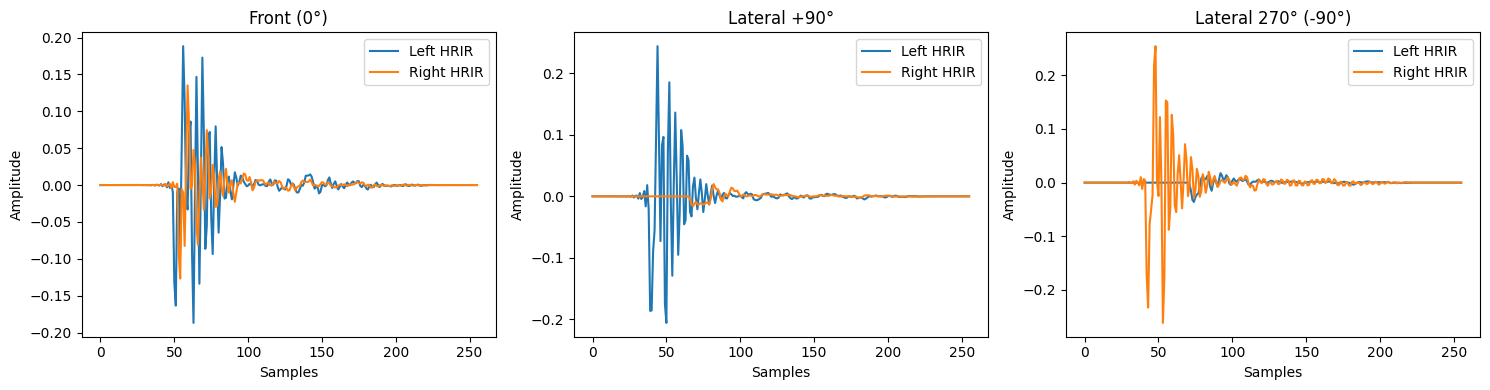

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, idx) in zip(axes, canonical.items()):
    left_hrir = hrir[subject_idx, idx, 0]
    right_hrir = hrir[subject_idx, idx, 1]
    ax.plot(left_hrir, label="Left HRIR")
    ax.plot(right_hrir, label="Right HRIR")
    ax.set_title(label)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude")
    ax.legend()
plt.tight_layout()
plt.show()

Notice that at the front direction, the left- and right-ear HRIRs are nearly identical (same path length, same filtering). At the lateral directions, the two ears diverge — one is the "near" ear (shorter path, less head shadowing) and the other is the "far" ear (delayed, attenuated by the head). This left/right asymmetry is the interaural time/level difference (ITD/ILD) that binaural rendering relies on for lateralization.

### 2b. HRTFs (magnitude spectra) at the same directions

Apply an FFT to each HRIR and look at the magnitude in dB — this is the frequency-domain view a neural field will actually learn to predict.

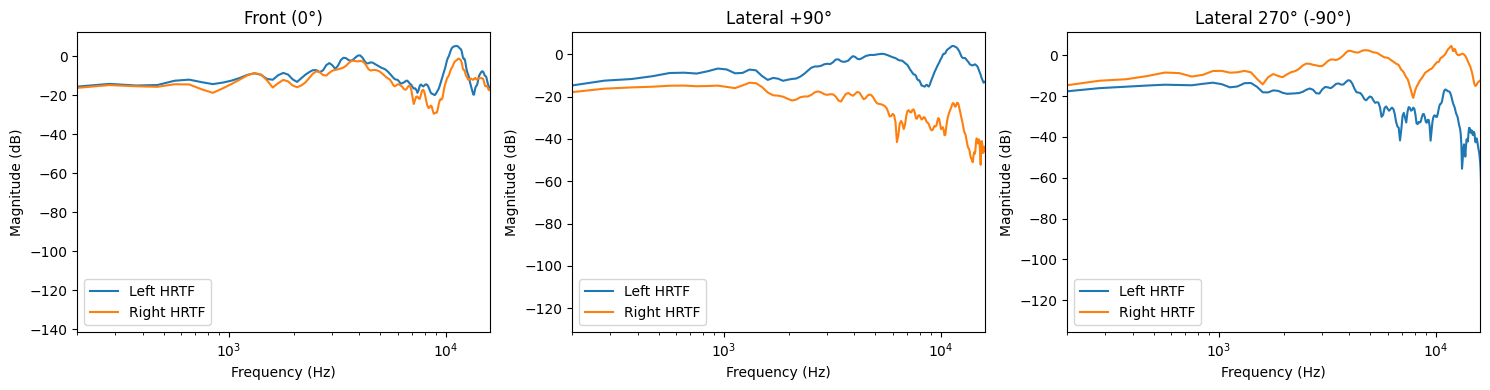

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, idx) in zip(axes, canonical.items()):
    freqs, left_db = hrir_to_hrtf_db(hrir[subject_idx, idx, 0], fs)
    _, right_db = hrir_to_hrtf_db(hrir[subject_idx, idx, 1], fs)
    ax.plot(freqs, left_db, label="Left HRTF")
    ax.plot(freqs, right_db, label="Right HRTF")
    ax.set_xscale("log")
    ax.set_xlim(200, 16000)
    ax.set_title(label)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.legend()
plt.tight_layout()
plt.show()

### 2c. Individual variation across subjects

Pinna shape, head size, and torso geometry all differ per person — so the same source direction produces a *different* HRTF for each subject. This individual variation is exactly the personalization problem the rest of the tutorial addresses (subject latents in Section 3+, anthropometric conditioning in the last notebook).

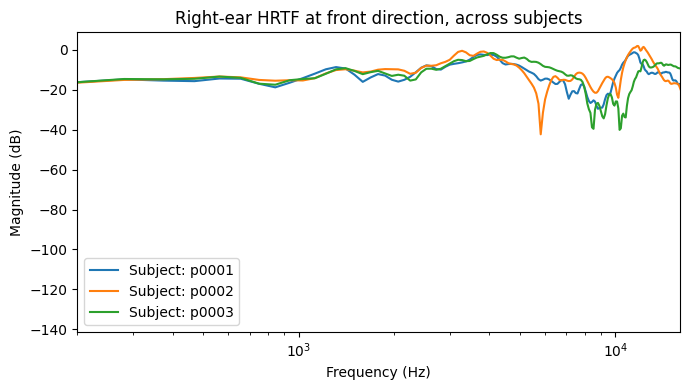

In [6]:
front_idx = canonical["Front (0°)"]
n_compare = min(3, hrir.shape[0])

fig, ax = plt.subplots(figsize=(7, 4))
for s in range(n_compare):
    freqs, mag_db = hrir_to_hrtf_db(hrir[s, front_idx, 1], fs)  # right ear, front direction
    ax.plot(freqs, mag_db, label=f"Subject: {subject_ids[s]}")
ax.set_xscale("log")
ax.set_xlim(200, 16000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Right-ear HRTF at front direction, across subjects")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Visualize the full directional sampling grid

Now zoom out from three example directions to the full measurement grid. This is the core motivation for neural fields: measurement directions are **fixed, irregular, and sparse** relative to the continuous sphere of possible source directions — SONICOM's real grid is denser near the horizontal plane and sparser toward the poles. A model that only works on this exact grid can't generalize to a direction that wasn't measured — a continuous neural-field representation can.

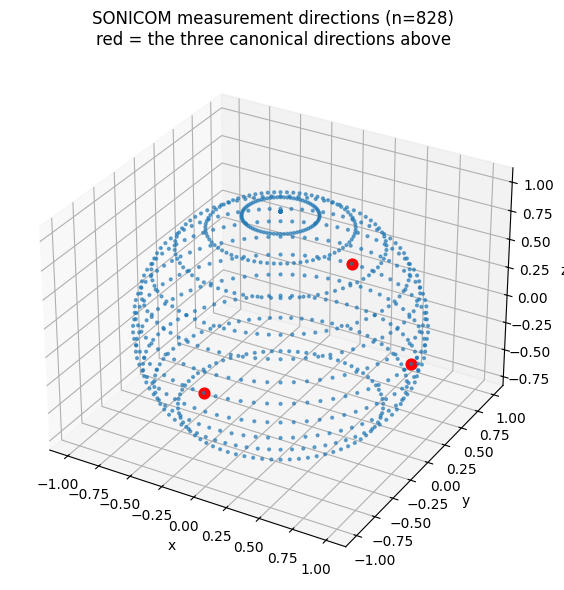

In [7]:
az = np.deg2rad(positions[:, 0])
el = np.deg2rad(positions[:, 1])
r = 1.0
x = r * np.cos(el) * np.cos(az)
y = r * np.cos(el) * np.sin(az)
z = r * np.sin(el)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=4, alpha=0.6)
for label, idx in canonical.items():
    ax.scatter(x[idx], y[idx], z[idx], s=60, c="red")
ax.set_title(f"SONICOM measurement directions (n={len(positions)})\nred = the three canonical directions above")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## Recap

- Binaural audio (unlike stereo) is built from ear-specific, direction-dependent filtering — the HRIR/HRTF
- Even at three simple directions, HRIRs/HRTFs already show clear ITD/ILD structure and differ across ears and subjects
- SONICOM HRTFs live on a fixed, irregular 793-direction grid per subject
- The magnitude spectrum varies smoothly-but-nontrivially with direction — this is the function a neural field learns to approximate

**Next:** `01_minimal_neural_field.ipynb` — train a minimal neural field that maps `(direction, subject latent) → HRTF magnitude`, following the HRTF Field formulation.